# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [10]:
# Load the dataset
file_path = 'resultados/sim_trace.csv'
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,4,COMP_M,Application-4,Application-4-Service,Sensor calling Service,6,35,23,1,Application-4-Sensor,Fog-0,Application-4-Sensor,0.02,114.000692,114.020692,100.0,114.000692
1,5,COMP_M,Application-5,Application-5-Service,Sensor calling Service,8,36,26,2,Application-5-Sensor,Fog-1,Application-5-Sensor,0.02,114.000692,114.020692,100.0,114.000692
2,7,COMP_M,Application-7,Application-7-Service,Sensor calling Service,12,38,32,4,Application-7-Sensor,Fog-3,Application-7-Sensor,0.02,114.000692,114.020692,100.0,114.000692
3,10,COMP_M,Application-10,Application-10-Service,Sensor calling Service,18,41,41,3,Application-10-Sensor,Fog-2,Application-10-Sensor,0.02,114.000692,114.020692,100.0,114.000692
4,11,COMP_M,Application-11,Application-11-Service,Sensor calling Service,20,42,44,4,Application-11-Sensor,Fog-3,Application-11-Sensor,0.02,114.000692,114.020692,100.0,114.000692


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3164 entries, 0 to 3163
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3164 non-null   int64  
 1   type            3164 non-null   object 
 2   app             3164 non-null   object 
 3   module          3164 non-null   object 
 4   message         3164 non-null   object 
 5   DES.src         3164 non-null   int64  
 6   DES.dst         3164 non-null   int64  
 7   TOPO.src        3164 non-null   int64  
 8   TOPO.dst        3164 non-null   int64  
 9   TOPO.srcLabel   3164 non-null   object 
 10  TOPO.dstLabel   3164 non-null   object 
 11  module.src      3164 non-null   object 
 12  service         3164 non-null   float64
 13  time_in         3164 non-null   float64
 14  time_out        3164 non-null   float64
 15  time_emit       3164 non-null   float64
 16  time_reception  3164 non-null   float64
dtypes: float64(5), int64(5), object(7

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `time_reception - time_emit`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [11]:
# Calculate Latency
df['Latency'] = df['time_reception'] - df['time_emit']

# Calculate Service Time (Processing Duration)
df['Service_Time'] = df['time_out'] - df['time_in']

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,3164.000000,3164.000000,3164.000000
mean,29.544804,0.508142,29.036662
std,19.883574,1.320993,19.044243
min,14.000346,0.000000,13.980692
25%,14.000692,0.000000,14.000346
50%,19.000817,0.020000,19.000408
75%,34.000351,0.020000,34.000351
max,94.000732,4.000000,90.000732


## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

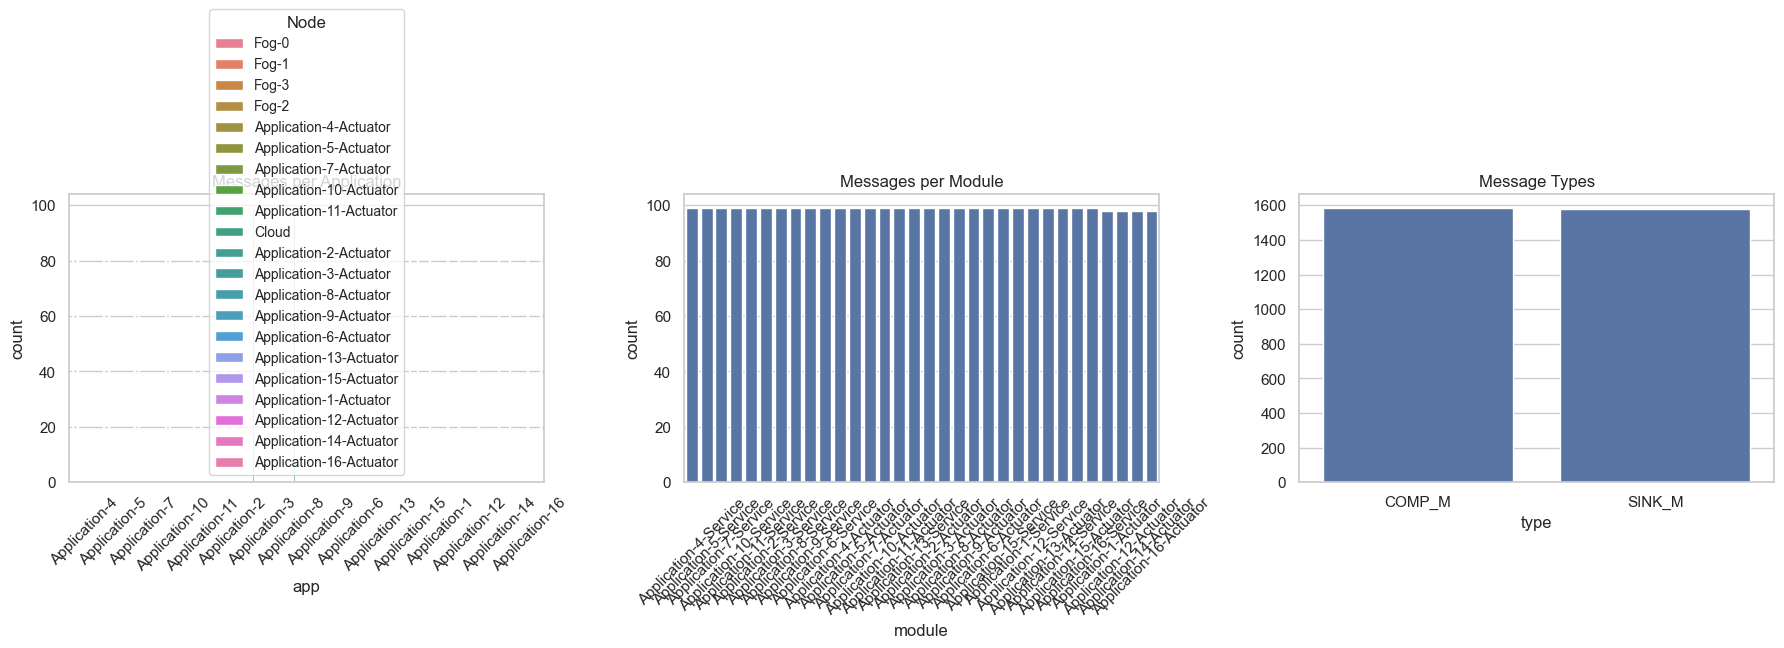

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Application Counts (broken down by Node)
sns.countplot(x='app', hue='TOPO.dstLabel', data=df, ax=axes[0])
axes[0].set_title('Messages per Application')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Node', fontsize='small')

# Module Counts
sns.countplot(x='module', data=df, ax=axes[1])
axes[1].set_title('Messages per Module')
axes[1].tick_params(axis='x', rotation=45)

# Message Type Counts
sns.countplot(x='type', data=df, ax=axes[2])
axes[2].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

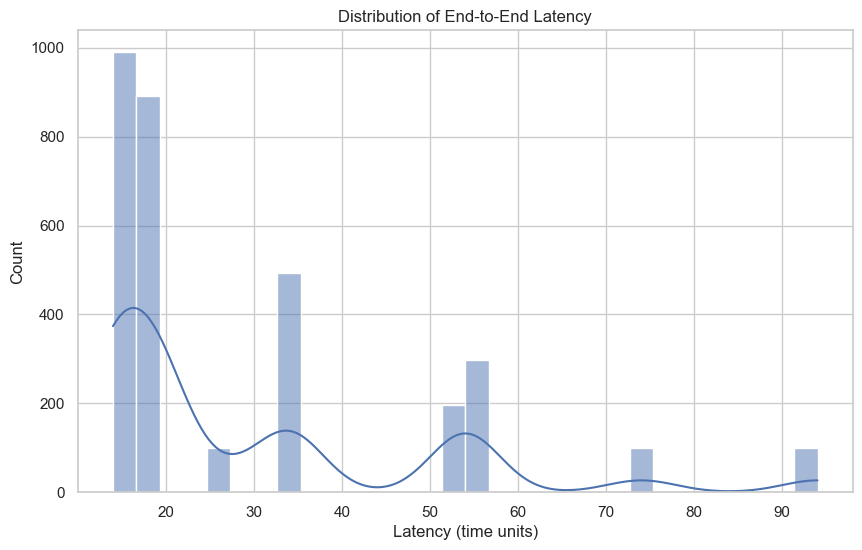

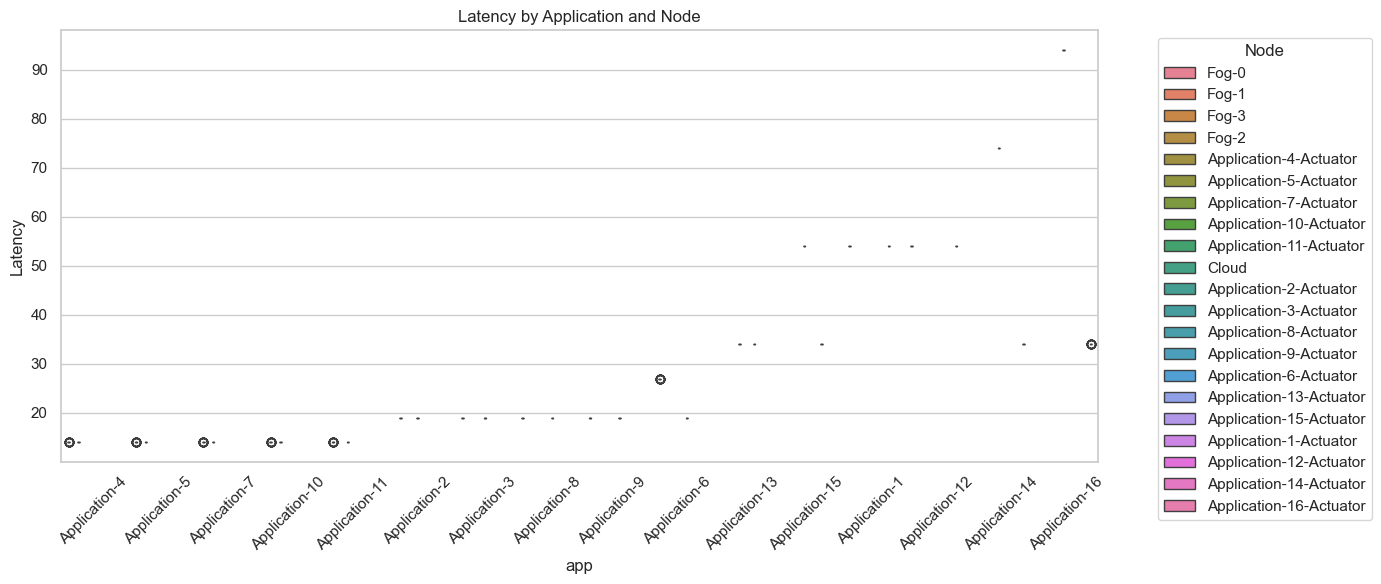

In [ ]:
# Latency Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Latency'], kde=True, bins=30)
plt.title('Distribution of End-to-End Latency')
plt.xlabel('Latency (time units)')
plt.show()

# Latency by Application
plt.figure(figsize=(12, 6))
sns.boxplot(x='app', y='Latency', data=df)
plt.title('Latency by Application')
plt.xticks(rotation=45)
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

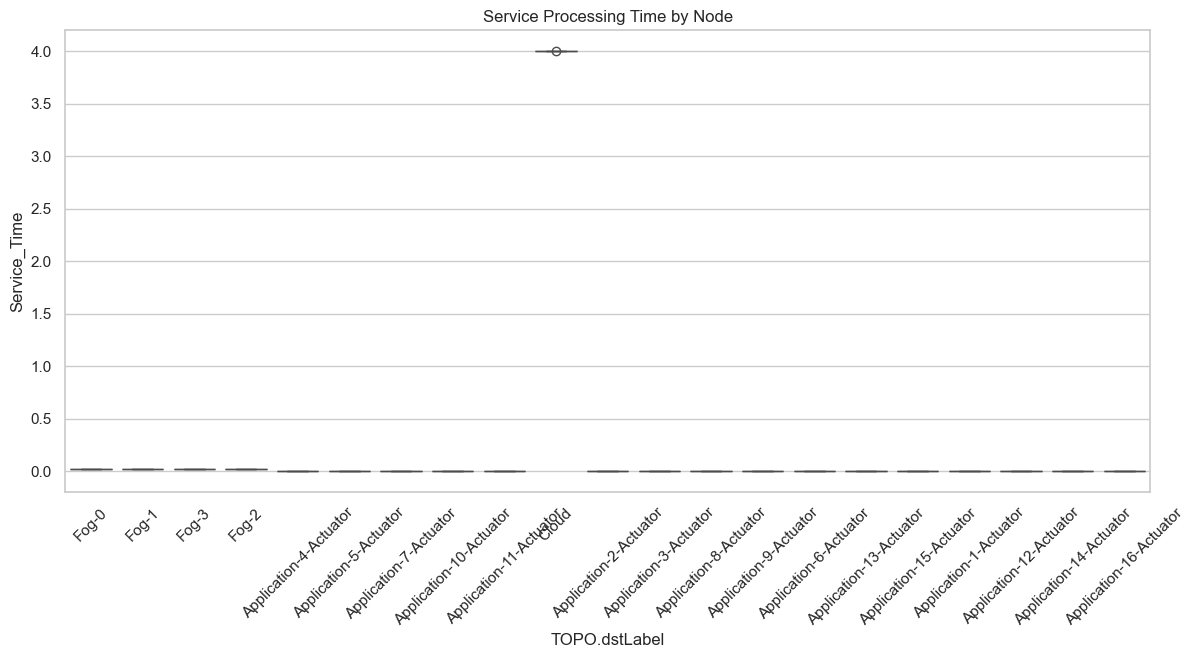

In [14]:
# Service Time by Node Label
plt.figure(figsize=(14, 6))
sns.boxplot(x='TOPO.dstLabel', y='Service_Time', data=df)
plt.title('Service Processing Time by Node')
plt.xticks(rotation=45)
plt.show()

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

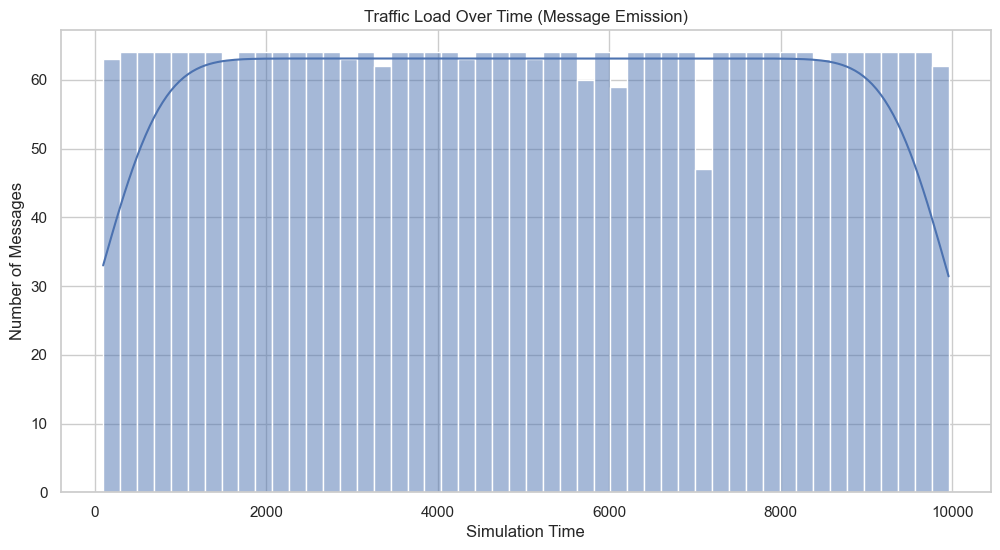

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df['time_emit'], bins=50, kde=True)
plt.title('Traffic Load Over Time (Message Emission)')
plt.xlabel('Simulation Time')
plt.ylabel('Number of Messages')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

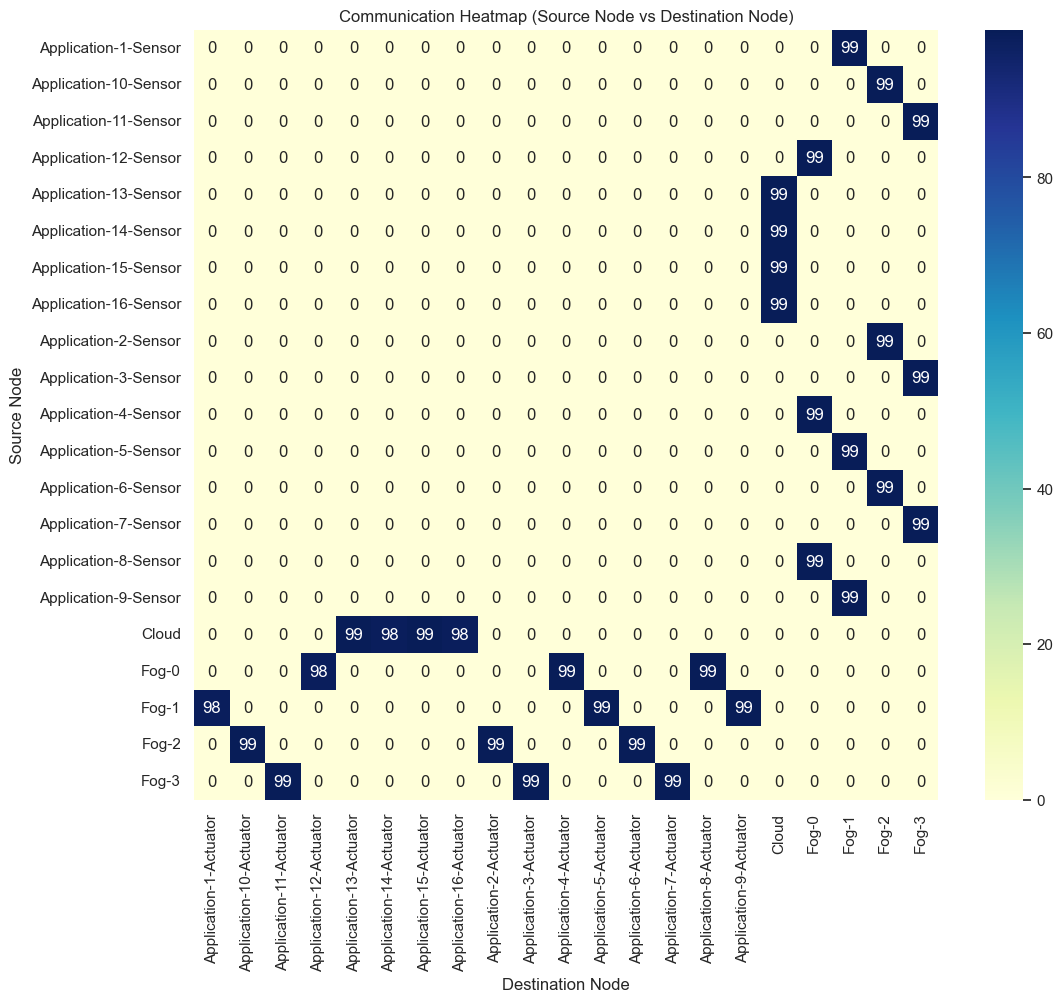

In [16]:
# Create a pivot table for the heatmap
heatmap_data = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Communication Heatmap (Source Node vs Destination Node)')
plt.xlabel('Destination Node')
plt.ylabel('Source Node')
plt.show()

## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).